In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores hiperparámetros: {'C': 10}
Mejor F1 macro score (validación cruzada): 0.6278466000820547

 Reporte de Clasificación:

                   precision    recall  f1-score   support

             edad       0.96      0.69      0.80      1979
            etnia       0.92      0.34      0.50      1408
           género       0.71      0.40      0.52      2455
not_ciberbullying       0.69      0.98      0.81      8009
             odio       0.84      0.46      0.59      1260
            otros       0.90      0.40      0.55       453

         accuracy                           0.73     15564
        macro avg       0.84      0.55      0.63     15564
     weighted avg       0.77      0.73      0.71     15564



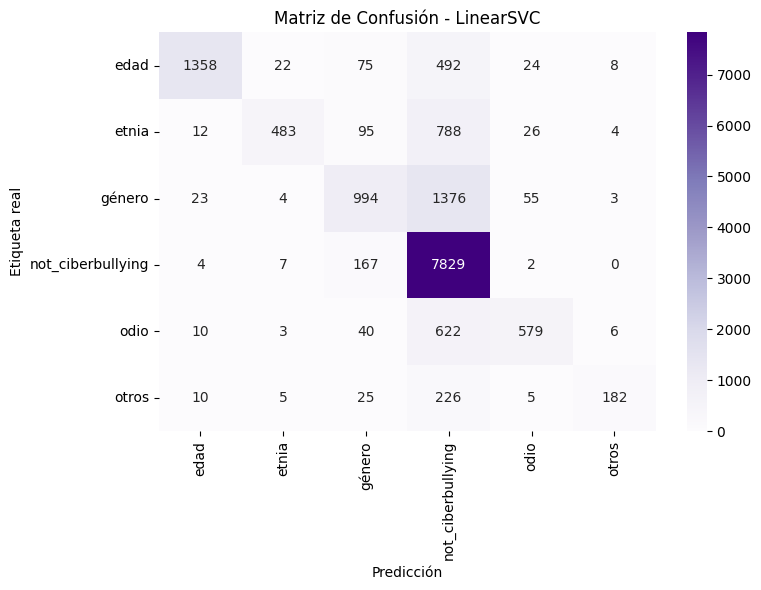

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df_balanceado = pd.read_csv('/content/drive/MyDrive/DATASET_TESIS_CIC/CLASIFICACIÓN/CB_balanceado_completo.csv')

X_raw = df_balanceado['text_cleaned']
y = df_balanceado['category_single']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=1000)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(
    LinearSVC(max_iter=5000, dual=False),
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print("Mejor F1 macro score (validación cruzada):", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n Reporte de Clasificación:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de Confusión - LinearSVC")
plt.tight_layout()
plt.show()
